In [89]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from scipy.stats import chi2
from astroquery.gaia import Gaia
import numpy as np
from astropy.time import Time
import plotly.graph_objects as go
from plotly.subplots import make_subplots
from matplotlib.ticker import MaxNLocator
from matplotlib.patches import Rectangle, Patch
from matplotlib.lines import Line2D
from matplotlib.ticker import MaxNLocator
from scipy.optimize import fsolve
import astropy.units as u
from astropy.constants import G

## Step 1: produce the dataframe with both LAMOST and Gaia radial velocities

In [106]:
df = pd.read_csv('Data/dr9_v2.0_MRS_stellar.csv')
df_candidates = pd.read_csv('Data/Results/sample_candidates.csv')

In [107]:
len(df_candidates)

33

In [114]:
candidates_list = df_candidates["designation"]
candidates_list = [item.removeprefix("LAMOST ") for item in candidates_list]
LAMOST_Gaia_df = df[df["designation"].isin(candidates_list)].drop_duplicates(subset = ["designation"])

### Substep: Retrieve Gaia radial velocities
Generate a file with list of gaia source ids and download the observations from https://gea.esac.esa.int/archive/

In [116]:
Gaia_id = [str(x) for x in LAMOST_Gaia_df['gaia_source_id'].tolist()]

with open('Data/candidates_Gaia_id', 'w') as file1:
	for item in Gaia_id:
		file1.write(f"Gaia DR3 {item}\n")

Save the csv file into Data folder and named it Gaia_RV.csv

In [93]:
#Filter out the sample df to only contain Designation, obsID & RV
df_sample = LAMOST_Gaia_df[['designation', 'gaia_source_id', 'rv_br1', 'rv_br1_err', 'obsdate']]
df_sample = df_sample.rename(columns={'rv_br1': 'radial_velocity', 'rv_br1_err': 'radial_velocity_error'})
obsdate_list = list(df_sample['obsdate'])
times = Time(obsdate_list, format='isot', scale='utc')
df_sample["epoch"] = times.mjd
df_sample["label"] = 'LAMOST MRS'

In [117]:
df_Gaia = pd.read_csv('Data/Gaia_RV.csv')

In [120]:
#read the df with Gaia radial velocity and add designation to it
df_Gaia = pd.read_csv('Data/Gaia_RV.csv')
df_Gaia = df_Gaia.rename(columns={'source_id': 'gaia_source_id'})
df_Gaia = df_Gaia[['gaia_source_id', 'radial_velocity', 'radial_velocity_error', 'ruwe', 'epoch', 'parallax']]
id2desig = dict(zip(df_sample['gaia_source_id'], df_sample['designation']))
df_Gaia['designation'] = df_Gaia['gaia_source_id'].map(id2desig)
df_Gaia = df_Gaia.drop_duplicates(subset = ['gaia_source_id'])
df_Gaia["epoch"] = 57382.84
df_Gaia["label"] = 'Gaia'

In [134]:
df_Gaia[["designation", "gaia_source_id"]]

,designation,gaia_source_id
0,J065401.91+752725.9,1115628342232842368
1,J151804.63+303904.1,1275559008641926400
2,J161726.91+323334.1,1322547153449845504
3,J042806.13+205315.1,144463771918611840
4,J130317.80+341230.1,1467971069600504064
5,J124707.83+381909.2,1520833527079026560
6,J131457.76+374110.5,1522817217854702592
7,J130052.89+524401.7,1558045432969998464
8,J043813.67+320004.8,159736263306222080
9,J143837.34+561633.6,1607632857626560512


In [122]:
df_sample_1 = df_sample[['designation', 'radial_velocity', 'radial_velocity_error', 'epoch', 'label']]
df_Gaia_1 = df_Gaia[['designation', 'radial_velocity', 'radial_velocity_error', 'epoch', 'label']]

# concat these two
df_RVs = pd.concat([df_sample_1, df_Gaia_1], ignore_index = True).dropna()

## Step 2: Calculate the chi2 of each radial velocity

J000045.08+062941.8
-160.15416499999998
-175.64 1.15
-144.66833 2.2442682
1.0130744372312786e-51


J000054.12+000557.2
-17.5182815
-14.86 2.62
-20.176563 4.7442393
0.2464366684161765


J000556.86-012835.5
-112.93658500000001
-117.47 1.01
-108.40317 1.5028275
6.372412017079379e-08


J000931.30-005813.9
47.4
47.4 2.36
nan


J005251.44+104310.4
172.51034049999998
536.51 2.39
-9.61 2.24
-9.3689785 2.877024
0.0


J010913.68+032459.7
-67.5975
-67.34 1.68
-72.23 1.61
-69.21 1.48
-62.42 1.49
-72.47 1.72
-60.44 2.02
-70.38 1.53
-66.29 1.49
7.915436930913914e-08


J033412.85+584631.7
-51.73641425
-46.41 1.98
-51.81 1.75
-53.87 1.7
-51.68 1.57
-53.1 1.56
-53.17 1.77
-51.95 1.58
-51.901314 0.2604137
0.15443137276970742


J035700.17+601505.5
-2.31
-0.25 1.8
-4.37 2.03
0.12612775435810805


J041912.65+563447.0
-43.98322433333333
-38.41 2.13
-42.53 1.89
-53.98 1.65
-42.6 2.2
-43.14 1.69
-43.239346 0.2809024
5.923973091888168e-10


J042806.13+205315.1
-53.935691
-55.4 1.95
-52.471382 4.368651
0.410883

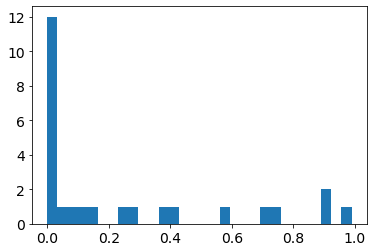

In [123]:
#Construct a dataframe with designation and mean radial velocities
df_mean = df_RVs.groupby('designation').mean('radial_velocity').reset_index()
Mean = df_mean['radial_velocity']

#Calculate the chi2 for each radial velocity
result = []
n_desig = df_mean['designation'].to_list() #number of designations (stars)
for i in range(len(n_desig)):
	desig = df_mean['designation'][i]
	print(desig)
	df_desig = df_RVs[df_RVs['designation'] == desig]
	n_obs = len(df_desig['designation'].tolist())
	mean = Mean.iloc[i]
	print(mean)
	f_exp = mean
	f_obs = np.zeros(1)
	f_err = np.zeros(1)
	for j in range(n_obs):
		RV = df_desig.iloc[j]['radial_velocity']
		RV_error = df_desig.iloc[j]['radial_velocity_error']
		f_obs = np.append(f_obs, RV)
		f_err = np.append(f_err, RV_error)  
		print(RV,RV_error)
	chi_square_statistic = np.sum(((f_obs[1:n_obs+1] - f_exp) / f_err[1:n_obs+1]) ** 2)
	degrees_of_freedom = n_obs - 1
	p = chi2.sf(chi_square_statistic, degrees_of_freedom)
	print(p)
	print('\n')
	result.append([desig, p])

df_chi2 = pd.DataFrame(result, columns=['designation', 'p-value'])
plt.hist(df_chi2['p-value'], bins=30)
candidates = df_chi2[df_chi2['p-value'] < 0.01]['designation'].tolist()

In [124]:
df_candidates_Gaia = df_Gaia[df_Gaia['designation'].isin(candidates)][['designation', 'ruwe', 'parallax']]
df_candidates = pd.merge(df_candidates_Gaia, df_chi2, on = 'designation')
# df_candidates.to_excel('/Users/mac/Desktop/table.xlsx')

In [126]:
df_candidates = df_candidates.sort_values(by="designation")
df_candidates

,designation,ruwe,parallax,p-value
7,J000045.08+062941.8,1.318706,3.540418,1.013074e-51
4,J000556.86-012835.5,1.223657,1.429329,6.372412e-08
6,J005251.44+104310.4,1.135965,6.385387,0.000000e+00
5,J010913.68+032459.7,1.095105,1.178630,7.915437e-08
8,J041912.65+563447.0,1.069349,0.361594,5.923973e-10
2,J043813.67+320004.8,0.953592,1.015558,8.147084e-03
0,J065401.91+752725.9,3.915628,3.320171,3.574110e-18
9,J104616.59+071939.8,1.028539,1.509397,3.373273e-17
3,J143837.34+561633.6,0.977247,0.910495,7.585882e-66
1,J161726.91+323334.1,0.983219,1.433590,7.551409e-05


In [131]:
parallax_mas = np.array(df_Gaia["parallax"])
parallax = 1/parallax_mas
np.median(parallax)

0.8934943152062023

In [101]:
df_final_candidates = df_candidates[(df_candidates['ruwe'] > 1.2) & (df_candidates['p-value'] < 0.05)]

In [102]:
df_final_candidates

,designation,ruwe,parallax,p-value
6,J000045.08+062941.8,1.318706,3.540418,1.013074e-51
4,J000556.86-012835.5,1.223657,1.429329,6.372412e-08
0,J065401.91+752725.9,3.915628,3.320171,3.574110e-18


In [ ]:
candidates_desig = list(df_final_candidates["designation"])
candidates_RVs = df_RVs[df_RVs["designation"].isin(candidates_desig)].sort_values(by = 'designation')
candidates_RVs.to_csv("Data/RV_Gaia_LAMOST.csv")